In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
######## Imports for modeling

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Dataset-Mental-Disorders.csv to Dataset-Mental-Disorders.csv


In [4]:

df = pd.read_csv("Dataset-Mental-Disorders.csv")

In [5]:
df.head()

,Patient Number,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,Patiant-01,Usually,Seldom,Sometimes,Sometimes,YES,YES,NO,NO,YES,NO,NO,YES,YES,YES,3 From 10,3 From 10,4 From 10,Bipolar Type-2
1,Patiant-02,Usually,Seldom,Usually,Sometimes,NO,YES,NO,NO,NO,NO,NO,NO,NO,NO,4 From 10,2 From 10,5 From 10,Depression
2,Patiant-03,Sometimes,Most-Often,Sometimes,Sometimes,YES,NO,NO,NO,YES,YES,NO,YES,YES,NO,6 From 10,5 From 10,7 From 10,Bipolar Type-1
3,Patiant-04,Usually,Seldom,Usually,Most-Often,YES,YES,YES,NO,YES,NO,NO,NO,NO,NO,3 From 10,2 From 10,2 From 10,Bipolar Type-2
4,Patiant-05,Usually,Usually,Sometimes,Sometimes,NO,NO,NO,NO,NO,NO,NO,YES,YES,YES,5 From 10,5 From 10,6 From 10,Normal


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Patient Number       120 non-null    object
 1   Sadness              120 non-null    object
 2   Euphoric             120 non-null    object
 3   Exhausted            120 non-null    object
 4   Sleep dissorder      120 non-null    object
 5   Mood Swing           120 non-null    object
 6   Suicidal thoughts    120 non-null    object
 7   Anorxia              120 non-null    object
 8   Authority Respect    120 non-null    object
 9   Try-Explanation      120 non-null    object
 10  Aggressive Response  120 non-null    object
 11  Ignore & Move-On     120 non-null    object
 12  Nervous Break-down   120 non-null    object
 13  Admit Mistakes       120 non-null    object
 14  Overthinking         120 non-null    object
 15  Sexual Activity      120 non-null    object
 16  Concentr

In [7]:
df.describe().transpose()

,count,unique,top,freq
Patient Number,120,120,Patiant-01,1
Sadness,120,4,Usually,42
Euphoric,120,4,Seldom,46
Exhausted,120,4,Sometimes,38
Sleep dissorder,120,4,Sometimes,44
Mood Swing,120,2,NO,63
Suicidal thoughts,120,3,NO,63
Anorxia,120,2,NO,74
Authority Respect,120,2,NO,73
Try-Explanation,120,2,NO,63


In [8]:
df.drop("Patient Number", axis=1, inplace=True)

In [9]:
print(f" Sadness labels: {df['Sadness'].unique()}")
print(f" Euphoric labels: {df['Euphoric'].unique()}")
print(df["Exhausted"].unique())
print(df["Sleep dissorder"].unique())

 Sadness labels: ['Usually' 'Sometimes' 'Seldom' 'Most-Often']
 Euphoric labels: ['Seldom' 'Most-Often' 'Usually' 'Sometimes']
['Sometimes' 'Usually' 'Seldom' 'Most-Often']
['Sometimes' 'Most-Often' 'Usually' 'Seldom']


In [10]:
df["Expert Diagnose"].unique()

array(['Bipolar Type-2', 'Depression', 'Bipolar Type-1', 'Normal'],
      dtype=object)

# Let's go through the features to identify each Disorder's Symptoms

**Explore the Symptoms of Depression**

In [11]:
depression_df = df.loc[df["Expert Diagnose"] == "Depression"]
depression_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 1 to 118
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Sadness              31 non-null     object
 1   Euphoric             31 non-null     object
 2   Exhausted            31 non-null     object
 3   Sleep dissorder      31 non-null     object
 4   Mood Swing           31 non-null     object
 5   Suicidal thoughts    31 non-null     object
 6   Anorxia              31 non-null     object
 7   Authority Respect    31 non-null     object
 8   Try-Explanation      31 non-null     object
 9   Aggressive Response  31 non-null     object
 10  Ignore & Move-On     31 non-null     object
 11  Nervous Break-down   31 non-null     object
 12  Admit Mistakes       31 non-null     object
 13  Overthinking         31 non-null     object
 14  Sexual Activity      31 non-null     object
 15  Concentration        31 non-null     object
 16  Optimisim     

In [12]:
#check the most common traits for each psychological feature
depression_df.describe().transpose()

,count,unique,top,freq
Sadness,31,3,Usually,15
Euphoric,31,2,Seldom,19
Exhausted,31,4,Usually,14
Sleep dissorder,31,4,Sometimes,13
Mood Swing,31,1,NO,31
Suicidal thoughts,31,2,YES,21
Anorxia,31,2,NO,21
Authority Respect,31,2,NO,25
Try-Explanation,31,2,NO,18
Aggressive Response,31,2,NO,22


In [35]:
sad = depression_df["Sadness"].value_counts()
print(f"the frequency of Sadness being found in patients with Depression: ")
print(f"{sad}")
print("\n")

insomniac = depression_df["Sleep dissorder"].value_counts()
print(f"the frequency of Sleep dissorder being found in patients with Depression: ")
print(f"{insomniac}")
print("\n")

suicidal = depression_df["Suicidal thoughts"].value_counts()
print(f"the frequency of Suicidal thoughts being seen in patients with Depression: ")
print(f"{suicidal}")
print("\n")

agression = depression_df["Aggressive Response"].value_counts()
print(f"the frequency of Aggressive Response being found in patients with Depression: ")
print(f"{agression}")
print("\n")

mood_swing = depression_df["Mood Swing"].value_counts()
print(f"the frequency of Mood Swing being found in Normal people: ")
print(f"{mood_swing}")
print("\n")

the frequency of Sadness being found in patients with Depression: 
Sadness
Usually       15
Most-Often    12
Sometimes      4
Name: count, dtype: int64


the frequency of Sleep dissorder being found in patients with Depression: 
Sleep dissorder
Sometimes     13
Most-Often     8
Usually        7
Seldom         3
Name: count, dtype: int64


the frequency of Suicidal thoughts being seen in patients with Depression: 
Suicidal thoughts
YES    21
NO     10
Name: count, dtype: int64


the frequency of Aggressive Response being found in patients with Depression: 
Aggressive Response
NO     22
YES     9
Name: count, dtype: int64


the frequency of Mood Swing being found in Normal people: 
Mood Swing
NO    31
Name: count, dtype: int64




**Now let'd explore the symptoms of a normal Human Being**

Compare people with no psychic issues with people having Depression

In [14]:
normal_df = df.loc[df["Expert Diagnose"] == "Normal"]
normal_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 4 to 119
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Sadness              30 non-null     object
 1   Euphoric             30 non-null     object
 2   Exhausted            30 non-null     object
 3   Sleep dissorder      30 non-null     object
 4   Mood Swing           30 non-null     object
 5   Suicidal thoughts    30 non-null     object
 6   Anorxia              30 non-null     object
 7   Authority Respect    30 non-null     object
 8   Try-Explanation      30 non-null     object
 9   Aggressive Response  30 non-null     object
 10  Ignore & Move-On     30 non-null     object
 11  Nervous Break-down   30 non-null     object
 12  Admit Mistakes       30 non-null     object
 13  Overthinking         30 non-null     object
 14  Sexual Activity      30 non-null     object
 15  Concentration        30 non-null     object
 16  Optimisim     

In [15]:
normal_df.describe().transpose()

,count,unique,top,freq
Sadness,30,3,Sometimes,20
Euphoric,30,4,Usually,11
Exhausted,30,4,Sometimes,16
Sleep dissorder,30,4,Seldom,13
Mood Swing,30,2,NO,29
Suicidal thoughts,30,2,NO,28
Anorxia,30,2,NO,23
Authority Respect,30,2,YES,20
Try-Explanation,30,2,NO,16
Aggressive Response,30,2,NO,19


In [34]:
sad = normal_df["Sadness"].value_counts()
print(f"the frequency of Sadness being found in Normal people: ")
print(f"{sad}")
print("\n")

insomniac = normal_df["Sleep dissorder"].value_counts()
print(f"the frequency of Sleep dissorder being found in Normal people: ")
print(f"{insomniac}")
print("\n")

suicidal = normal_df["Suicidal thoughts"].value_counts()
print(f"the frequency of Suicidal thoughts being seen in Normal people: ")
print(f"{suicidal}")
print("\n")

agression = normal_df["Aggressive Response"].value_counts()
print(f"the frequency of Aggressive Response being found in Normal people: ")
print(f"{agression}")
print("\n")

mood_swing = normal_df["Mood Swing"].value_counts()
print(f"the frequency of Mood Swing being found in Normal people: ")
print(f"{mood_swing}")
print("\n")

the frequency of Sadness being found in Normal people: 
Sadness
Sometimes    20
Seldom        6
Usually       4
Name: count, dtype: int64


the frequency of Sleep dissorder being found in Normal people: 
Sleep dissorder
Seldom        13
Sometimes      8
Usually        8
Most-Often     1
Name: count, dtype: int64


the frequency of Suicidal thoughts being seen in Normal people: 
Suicidal thoughts
NO     28
YES     2
Name: count, dtype: int64


the frequency of Aggressive Response being found in Normal people: 
Aggressive Response
NO     19
YES    11
Name: count, dtype: int64


the frequency of Mood Swing being found in Normal people: 
Mood Swing
NO     29
YES     1
Name: count, dtype: int64




In [17]:
df.columns

Index(['Sadness', 'Euphoric', 'Exhausted', 'Sleep dissorder', 'Mood Swing',
       'Suicidal thoughts', 'Anorxia', 'Authority Respect', 'Try-Explanation',
       'Aggressive Response', 'Ignore & Move-On', 'Nervous Break-down',
       'Admit Mistakes', 'Overthinking', 'Sexual Activity', 'Concentration',
       'Optimisim', 'Expert Diagnose'],
      dtype='object')

In [18]:
rating_outof_ten_columns = ['Sexual Activity', 'Concentration', 'Optimisim']

for col in rating_outof_ten_columns:
    df[col] = df[col].str.split(" ").str[0].astype(int)


df.head()

,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,Usually,Seldom,Sometimes,Sometimes,YES,YES,NO,NO,YES,NO,NO,YES,YES,YES,3,3,4,Bipolar Type-2
1,Usually,Seldom,Usually,Sometimes,NO,YES,NO,NO,NO,NO,NO,NO,NO,NO,4,2,5,Depression
2,Sometimes,Most-Often,Sometimes,Sometimes,YES,NO,NO,NO,YES,YES,NO,YES,YES,NO,6,5,7,Bipolar Type-1
3,Usually,Seldom,Usually,Most-Often,YES,YES,YES,NO,YES,NO,NO,NO,NO,NO,3,2,2,Bipolar Type-2
4,Usually,Usually,Sometimes,Sometimes,NO,NO,NO,NO,NO,NO,NO,YES,YES,YES,5,5,6,Normal


In [19]:
binary_columns = ["Mood Swing", "Suicidal thoughts", "Anorxia", "Authority Respect", "Try-Explanation", "Aggressive Response", 'Ignore & Move-On', 'Nervous Break-down',
       'Admit Mistakes', 'Overthinking']


for col in binary_columns:
    df[col] = df[col].map({'YES': 1, 'NO': 0})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sadness              120 non-null    object 
 1   Euphoric             120 non-null    object 
 2   Exhausted            120 non-null    object 
 3   Sleep dissorder      120 non-null    object 
 4   Mood Swing           120 non-null    int64  
 5   Suicidal thoughts    119 non-null    float64
 6   Anorxia              120 non-null    int64  
 7   Authority Respect    120 non-null    int64  
 8   Try-Explanation      120 non-null    int64  
 9   Aggressive Response  120 non-null    int64  
 10  Ignore & Move-On     120 non-null    int64  
 11  Nervous Break-down   120 non-null    int64  
 12  Admit Mistakes       120 non-null    int64  
 13  Overthinking         120 non-null    int64  
 14  Sexual Activity      120 non-null    int64  
 15  Concentration        120 non-null    int

In [20]:
df.head()

,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,Usually,Seldom,Sometimes,Sometimes,1,NaN,0,0,1,0,0,1,1,1,3,3,4,Bipolar Type-2
1,Usually,Seldom,Usually,Sometimes,0,1.0,0,0,0,0,0,0,0,0,4,2,5,Depression
2,Sometimes,Most-Often,Sometimes,Sometimes,1,0.0,0,0,1,1,0,1,1,0,6,5,7,Bipolar Type-1
3,Usually,Seldom,Usually,Most-Often,1,1.0,1,0,1,0,0,0,0,0,3,2,2,Bipolar Type-2
4,Usually,Usually,Sometimes,Sometimes,0,0.0,0,0,0,0,0,1,1,1,5,5,6,Normal


In [21]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

categorical_columns = ['Sadness', 'Euphoric', 'Exhausted', 'Sleep dissorder']

for col in categorical_columns:
  df[col] = df[col].map({"Seldom": 1, "Sometimes": 2, "Most-Often": 3, "Usually": 4})


df.head()

,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,4,1,2,2,1,NaN,0,0,1,0,0,1,1,1,3,3,4,Bipolar Type-2
1,4,1,4,2,0,1.0,0,0,0,0,0,0,0,0,4,2,5,Depression
2,2,3,2,2,1,0.0,0,0,1,1,0,1,1,0,6,5,7,Bipolar Type-1
3,4,1,4,3,1,1.0,1,0,1,0,0,0,0,0,3,2,2,Bipolar Type-2
4,4,4,2,2,0,0.0,0,0,0,0,0,1,1,1,5,5,6,Normal


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sadness              120 non-null    int64  
 1   Euphoric             120 non-null    int64  
 2   Exhausted            120 non-null    int64  
 3   Sleep dissorder      120 non-null    int64  
 4   Mood Swing           120 non-null    int64  
 5   Suicidal thoughts    119 non-null    float64
 6   Anorxia              120 non-null    int64  
 7   Authority Respect    120 non-null    int64  
 8   Try-Explanation      120 non-null    int64  
 9   Aggressive Response  120 non-null    int64  
 10  Ignore & Move-On     120 non-null    int64  
 11  Nervous Break-down   120 non-null    int64  
 12  Admit Mistakes       120 non-null    int64  
 13  Overthinking         120 non-null    int64  
 14  Sexual Activity      120 non-null    int64  
 15  Concentration        120 non-null    int

In [23]:
from sklearn.preprocessing import LabelEncoder

# 5. Label Encoding for the target variable (Expert Diagnose)
label_encoder = LabelEncoder()
df['Expert Diagnose'] = label_encoder.fit_transform(df['Expert Diagnose'])

In [24]:
df['Expert Diagnose'].unique()

array([1, 2, 0, 3])

In [25]:
df.head()

,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,4,1,2,2,1,NaN,0,0,1,0,0,1,1,1,3,3,4,1
1,4,1,4,2,0,1.0,0,0,0,0,0,0,0,0,4,2,5,2
2,2,3,2,2,1,0.0,0,0,1,1,0,1,1,0,6,5,7,0
3,4,1,4,3,1,1.0,1,0,1,0,0,0,0,0,3,2,2,1
4,4,4,2,2,0,0.0,0,0,0,0,0,1,1,1,5,5,6,3


In [26]:
pr = df["Suicidal thoughts"].value_counts()
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119 entries, 1 to 119
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sadness              119 non-null    int64  
 1   Euphoric             119 non-null    int64  
 2   Exhausted            119 non-null    int64  
 3   Sleep dissorder      119 non-null    int64  
 4   Mood Swing           119 non-null    int64  
 5   Suicidal thoughts    119 non-null    float64
 6   Anorxia              119 non-null    int64  
 7   Authority Respect    119 non-null    int64  
 8   Try-Explanation      119 non-null    int64  
 9   Aggressive Response  119 non-null    int64  
 10  Ignore & Move-On     119 non-null    int64  
 11  Nervous Break-down   119 non-null    int64  
 12  Admit Mistakes       119 non-null    int64  
 13  Overthinking         119 non-null    int64  
 14  Sexual Activity      119 non-null    int64  
 15  Concentration        119 non-null    int64  


In [30]:
X = df.drop("Expert Diagnose", axis=1)
y = df["Expert Diagnose"]


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [32]:


logistic_model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=200)

logistic_model.fit(x_train, y_train)
predictions = logistic_model.predict(x_test)


print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.75      0.86         8
           2       0.89      1.00      0.94         8
           3       1.00      1.00      1.00         4

    accuracy                           0.92        24
   macro avg       0.92      0.94      0.92        24
weighted avg       0.93      0.92      0.91        24



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


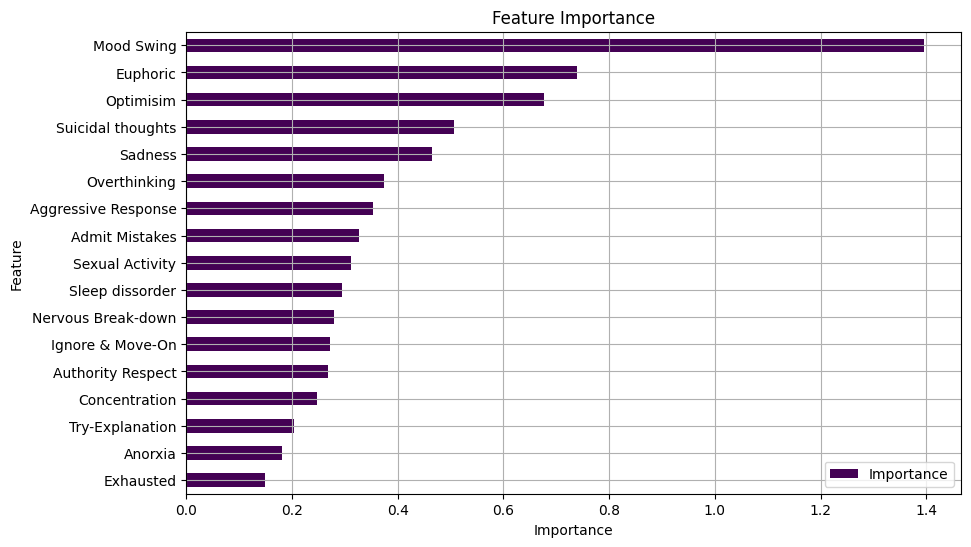

In [39]:
import numpy as np


coefficients = logistic_model.coef_


avg_importance = np.mean(np.abs(coefficients), axis=0)
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': avg_importance})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6), cmap='viridis')
plt.grid()
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

In [ ]:
questions =